# Data Cleaning on an E-Commerce Dataset

## Project Objective

This project focuses on cleaning and improving the quality of a raw dataset through a structured data cleaning workflow. The process includes inspecting the dataset, identifying data quality issues, handling missing and duplicate values, standardizing inconsistent entries, correcting data types, and investigating potentially unusual values.

The goal is to produce a clean, consistent, and reliable dataset that is ready for further analysis.

## Dataset Overview

The dataset contains 61 records and includes information across multiple features. Before the cleaning process, the dataset was examined to understand its structure, data types, missing values, duplicate records, categorical values, and potentially unusual entries.

The dataset was then cleaned and validated to improve its consistency and prepare it for subsequent data analysis.

## Tools & Libraries


* Python
* Pandas
* Matplotlib

## Workflow

- Import Libraries
- Load and Inspect the Dataset
- Understand Dataset Structure and Features
- Assess Data Quality
- Handle Missing Values
- Handle Duplicate Records
- Categorical Value Inspection
- Standardize and Correct Inconsistent Values
- Correct Data Types
- Inspect Potential Outliers & Unusual Values
- Save the Cleaned Dataset
- Conclusion

 ## Data Loading & Initial Inspection

In [45]:
#Import_Libraries

import pandas as pd
import matplotlib.pyplot as plt


In [46]:
#load_dataset

Data = pd.read_excel("../data/FirstDataset.xlsx")

#dataframe

df = pd.DataFrame(Data)

### Dataset Information

In [47]:
Data.head(5)

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [48]:
df.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,61.000000,60.000000,61.000000,61.000000,60.000000,61.000000,61.000000,61.00000
mean,1030.229508,45.200000,17.606557,211.435738,3749.667333,196.934426,4.196721,3.00000
std,17.446483,19.167239,10.214824,130.113726,4262.248522,97.892436,2.663454,1.42595
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.00000
25%,1015.000000,31.750000,11.000000,108.190000,1167.035000,132.000000,2.000000,2.00000
50%,1030.000000,45.000000,17.000000,161.330000,2188.865000,201.000000,4.000000,3.00000
75%,1045.000000,58.000000,26.000000,323.320000,4692.150000,273.000000,7.000000,4.00000
max,1060.000000,145.000000,35.000000,449.810000,25000.000000,365.000000,8.000000,5.00000


In [49]:
#Number_of_Rows_Columns

rows,columns= df.shape
print(f"Number of rows in this dataset is: {rows}")
print(f"Number of columns in this dataset is: {columns}")

Number of rows in this dataset is: 61
Number of columns in this dataset is: 17


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         61 non-null     int64  
 1   first_name          61 non-null     object 
 2   gender              61 non-null     object 
 3   age                 60 non-null     float64
 4   city                61 non-null     object 
 5   province            61 non-null     object 
 6   signup_date         61 non-null     object 
 7   membership_tier     61 non-null     object 
 8   purchase_count      61 non-null     int64  
 9   avg_order_value     61 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  61 non-null     int64  
 12  payment_method      61 non-null     object 
 13  device              61 non-null     object 
 14  discount_used       61 non-null     object 
 15  returned_items      61 non-null     int64  
 16  satisfacti

In [51]:
#Column_names

df.columns

Index(['customer_id', 'first_name', 'gender', 'age', 'city', 'province',
       'signup_date', 'membership_tier', 'purchase_count', 'avg_order_value',
       'total_spending', 'last_purchase_days', 'payment_method', 'device',
       'discount_used', 'returned_items', 'satisfaction_score'],
      dtype='object')

In [52]:
#Column_Details

def col_detail (df):
    col_name = []
    dtypes = []
    count = []
    unique = []
    for col in df.columns:
        col_name.append(col)
        dtypes.append(df[col].dtype)
        count.append(len(df[col]))
        unique.append(len(df[col].unique()))
        
    output = pd.DataFrame({
        'Column_name' : col_name,
        'Dtype' : dtypes,
        'Count' : count,
        'Unique': unique
    })
    return output

col_detail(df)

,Column_name,Dtype,Count,Unique
0,customer_id,int64,61,60
1,first_name,object,61,12
2,gender,object,61,2
3,age,float64,61,35
4,city,object,61,8
5,province,object,61,8
6,signup_date,object,61,58
7,membership_tier,object,61,4
8,purchase_count,int64,61,30
9,avg_order_value,float64,61,60


## Data Quality Assessment

### Missing Values

In [53]:
#number_of_missing_values

num_miss = df.isna().sum().sum()

if num_miss == 0:
    print("There is no missing values in this dataset.")
else:
    print(f"There are {num_miss} missing values in this dataset!")

There are 2 missing values in this dataset!


In [54]:
#number_of_missing_values_in_each_col

for col in df.columns:
    num_missing = df[col].isna().sum().sum()
    print(col, num_missing)

customer_id 0
first_name 0
gender 0
age 1
city 0
province 0
signup_date 0
membership_tier 0
purchase_count 0
avg_order_value 0
total_spending 1
last_purchase_days 0
payment_method 0
device 0
discount_used 0
returned_items 0
satisfaction_score 0


In [55]:
#Display_rows_with_missing_values
df[df.isnull().any(axis=1)]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
19,1020,Kimia,M,NaN,Isfahan,Isfahan,2024-06-25,Bronze,16,187.17,2994.72,4,Cash,Web,Yes,1,5
39,1040,Amir,F,65.0,Tehran,Tehran,2021-11-02,Bronze,34,37.66,NaN,126,Card,Android,Yes,3,2


Given the relatively small size of the dataset (61 rows × 17 columns) and the presence of only two missing values, I chose to retain the available records rather than remove rows with missing data.


- For `customer_id` 1020, the missing `age` value was imputed using the median age, as the median is less sensitive to potential outliers than the mean.
- For `customer_id` 1040, the missing `total_spending` value was calculated using the relationship `purchase_count` × `avg_order_value`. 

This approach was validated by comparing the calculated values for several existing records with their recorded `total_spending` values, which matched exactly.


This approach preserves the dataset while using the available information and the underlying relationships between variables to handle the missing values.

In [56]:
# index_19
# Median_Age

median_age = df['age'].median()
df.loc[19, 'age'] = median_age

# index_39
# Calculate_total_spending

df.loc[39, 'total_spending'] = (df.loc[39, 'purchase_count'] * df.loc[39, 'avg_order_value'])

In [57]:
#validate
df.loc[[19, 39], ['customer_id', 'age', 'purchase_count', 'avg_order_value', 'total_spending']]

,customer_id,age,purchase_count,avg_order_value,total_spending
19,1020,45.0,16,187.17,2994.72
39,1040,65.0,34,37.66,1280.44


In [58]:
df.isna().sum()

customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64

After applying the selected imputation methods, the dataset contains no remaining missing values.

### Duplicate Records

In [59]:
#number_of_duplicate_records

num_dup = df.duplicated().sum()

if num_dup ==0:
    print("There is no duplicate rows in this dataset.")
elif num_dup ==1:
    print("There is one duplicate row in this dataset.")
else:
    print(f"There are {num_dup} duplicate rows in this dataset.")

There is one duplicate row in this dataset.


In [60]:
#Display_duplicate_record

df[df.duplicated(keep=False)]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
13,1014,Reza,M,35.0,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4
60,1014,Reza,M,35.0,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4


In [61]:
#remove_duplicate_record
df = df.drop_duplicates()

Duplicate records were identified and removed before continuing with the exploratory analysis. The analysis therefore uses the deduplicated dataset.

### Categorical Value Inspection

In [62]:

for column in df.columns:
    print(f"Unique Values in '{column}':")
    print(df[column].unique())
    print("_"*40)

Unique Values in 'customer_id':
[1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014
 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028
 1029 1030 1031 1032 1033 1034 1035 1036 1037 1038 1039 1040 1041 1042
 1043 1044 1045 1046 1047 1048 1049 1050 1051 1052 1053 1054 1055 1056
 1057 1058 1059 1060]
________________________________________
Unique Values in 'first_name':
['Reza' 'Sina' 'Parsa' 'Kimia' 'Amir' 'Arash' 'Neda' 'Ali' 'Mina' 'Zahra'
 'Maryam' 'Sara']
________________________________________
Unique Values in 'gender':
['F' 'M']
________________________________________
Unique Values in 'age':
[ 19.  53.  31.  58.  28.  43.  23.  61. 145.  41.  51.  39.  35.  47.
  45.  49.  30.  22.  50.  60.  37.  25.  34.  63.  26.  42.  65.  64.
  54.  32.  48.  59.  62.  57.]
________________________________________
Unique Values in 'city':
['Karaj' 'Tehran' 'Shiraz' 'Mashhad' 'Isfahan' 'Rasht' 'Tabriz' 'Ahvaz']
________________________________________
U

### Standardizing Categorical Values

In [63]:
df['payment_method'] = df['payment_method'].replace('Online Wallet', 'Online_Wallet')

In [64]:
df['payment_method'].unique()

array(['Card', 'Online_Wallet', 'Cash'], dtype=object)

The `payment_method` values were standardized by replacing the space in `Online Wallet` with an underscore to maintain consistent naming across categorical values.

### Inconsistent Values

In [65]:
df['first_name'].value_counts()

first_name
Sina      8
Neda      8
Reza      7
Kimia     7
Amir      6
Ali       6
Parsa     4
Arash     4
Maryam    4
Mina      3
Zahra     2
Sara      1
Name: count, dtype: int64

In [66]:
df[['customer_id', 'first_name', 'gender']].sort_values('first_name')

,customer_id,first_name,gender
59,1060,Ali,M
28,1029,Ali,F
58,1059,Ali,F
22,1023,Ali,F
48,1049,Ali,F
17,1018,Ali,F
57,1058,Amir,F
5,1006,Amir,F
20,1021,Amir,F
39,1040,Amir,F


In [67]:
# Correct inconsistent gender values based on first_name

gender_mapping = {
    'Ali': 'M',
    'Amir': 'M',
    'Arash': 'M',
    'Kimia': 'F',
    'Maryam': 'F',
    'Mina': 'F',
    'Neda': 'F',
    'Parsa': 'M',
    'Reza': 'M',
    'Sara': 'F',
    'Sina': 'M',
    'Zahra': 'F'
}

df['gender'] = df['first_name'].map(gender_mapping)

In [68]:
#Validate

pd.crosstab(df['first_name'], df['gender'])

gender,F,M
first_name,,
Ali,0,6
Amir,0,6
Arash,0,4
Kimia,7,0
Maryam,4,0
Mina,3,0
Neda,8,0
Parsa,0,4
Reza,0,7


The `gender` values were corrected based on the corresponding `first_name`. The result was validated using a cross-tabulation, confirming that each first name is now consistently associated with the expected gender.

### Data Types

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         60 non-null     int64  
 1   first_name          60 non-null     object 
 2   gender              60 non-null     object 
 3   age                 60 non-null     float64
 4   city                60 non-null     object 
 5   province            60 non-null     object 
 6   signup_date         60 non-null     object 
 7   membership_tier     60 non-null     object 
 8   purchase_count      60 non-null     int64  
 9   avg_order_value     60 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  60 non-null     int64  
 12  payment_method      60 non-null     object 
 13  device              60 non-null     object 
 14  discount_used       60 non-null     object 
 15  returned_items      60 non-null     int64  
 16  satisfaction_sc

In [70]:

str_columns = ['first_name','gender','city','province','membership_tier','payment_method','device','discount_used']

# Convert_to_string
df[str_columns] = df[str_columns].astype('string')

# Convert signup_date to datetime
df['signup_date'] = pd.to_datetime(df['signup_date'])

# float to integer
df['age'] = df['age'].astype('int')

In [71]:
# Validate

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     string        
 2   gender              60 non-null     string        
 3   age                 60 non-null     int64         
 4   city                60 non-null     string        
 5   province            60 non-null     string        
 6   signup_date         60 non-null     datetime64[ns]
 7   membership_tier     60 non-null     string        
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     string        
 13  device              60 non-null     string        
 14  d

### Potential Noise & Outliers

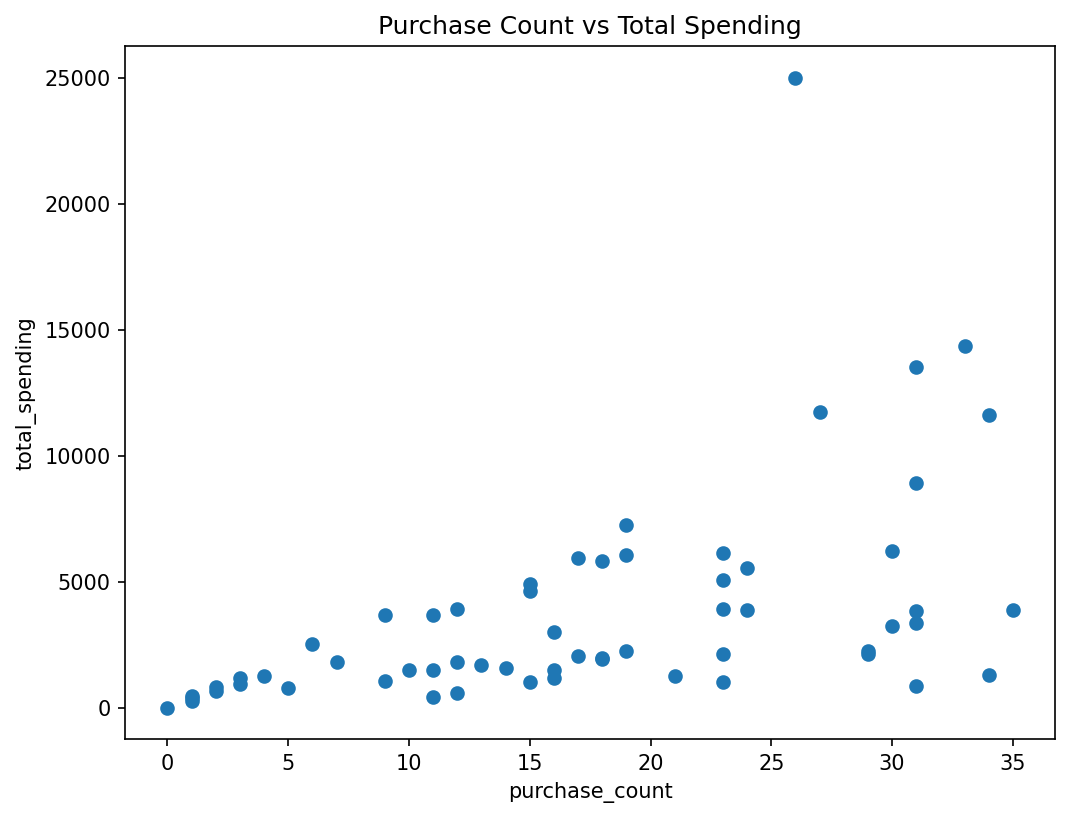

In [72]:

plt.figure(figsize=(8,6) , dpi=150)

plt.scatter(
    df['purchase_count'],
    df['total_spending']
)

plt.xlabel('purchase_count')
plt.ylabel('total_spending')
plt.title('Purchase Count vs Total Spending')

plt.show()

In [73]:
df[df["total_spending"] > 20000]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
29,1030,Sina,M,60,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,25000.0,340,Cash,Web,Yes,4,4


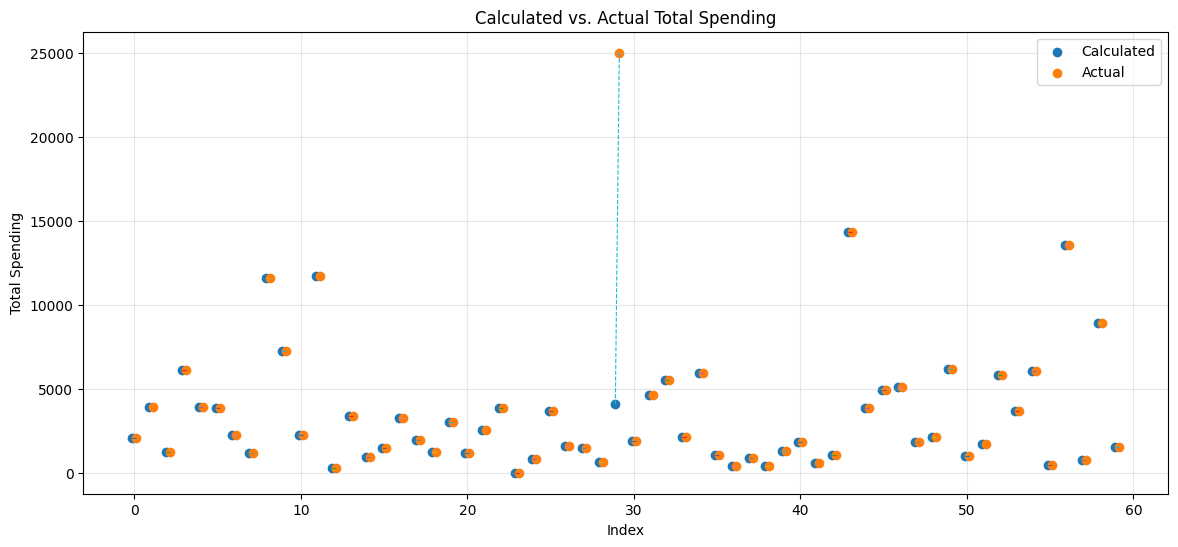

In [74]:

# Calculate expected total spending
calculated_spending = (
    df['purchase_count'] * df['avg_order_value']
)

plt.figure(figsize=(14, 6))

# Slight horizontal offset so overlapping points remain visible
x_calculated = df.index - 0.12
x_actual = df.index + 0.12

# Calculated values
plt.scatter(x_calculated, calculated_spending, label='Calculated')

# Actual values
plt.scatter(x_actual,df['total_spending'], label='Actual')

# Connect calculated and actual values
for i in df.index:
    plt.plot(
        [i - 0.12, i + 0.12],
        [calculated_spending.loc[i], df.loc[i, 'total_spending']],
        linestyle='--',
        linewidth=0.8)

plt.xlabel('Index')
plt.ylabel('Total Spending')
plt.title('Calculated vs. Actual Total Spending')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [75]:
# Calculate total spending

df.loc[df['customer_id'] == 1030, 'total_spending'] = (df.loc[df['customer_id'] == 1030, 'purchase_count'] *
    df.loc[df['customer_id'] == 1030, 'avg_order_value'])

In [76]:
# Validate

df.loc[df['customer_id'] == 1030]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
29,1030,Sina,M,60,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,4079.14,340,Cash,Web,Yes,4,4


An inconsistency was identified for `customer_id` 1030, where `total_spending` did not match the relationship between `purchase_count` and `avg_order_value`. Since the calculated value was consistent with the recorded values across the rest of the dataset, `total_spending` was corrected accordingly.


### Potentially Unusual Values

In [77]:
df[df['purchase_count'] == 0]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
23,1024,Sina,M,53,Ahvaz,Khuzestan,2025-01-27,Gold,0,63.67,0.0,298,Online_Wallet,Android,No,2,1


In [78]:
df[df['purchase_count']== 0]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
23,1024,Sina,M,53,Ahvaz,Khuzestan,2025-01-27,Gold,0,63.67,0.0,298,Online_Wallet,Android,No,2,1


In [79]:
df[df['avg_order_value']== 0]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


One record has zero `purchase_count` and `total_spending` . Since there is insufficient evidence to confirm it as an invalid record, it was retained.

In [80]:
# age > 100

df[df['age'] > 100]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
9,1010,Arash,M,145,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online_Wallet,Android,No,7,1


In [81]:
# Correct an invalid age value
df.loc[df['customer_id'] == 1010, 'age'] = 45

In [82]:
# Validate

df[df['age'] > 100]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


In [83]:
df['age'].describe()

count    60.000000
mean     43.700000
std      13.946994
min      19.000000
25%      31.750000
50%      45.000000
75%      58.000000
max      65.000000
Name: age, dtype: float64

An invalid age value of 145 was identified for `customer_id` 1010. Since this value falls outside a plausible customer `age` range and was inconsistent with the overall distribution of the dataset, it was corrected to 45.

In [84]:
df[ (df['last_purchase_days'] < 0) | (df['last_purchase_days'] > 365)]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


In [85]:
df[df['returned_items'] < 0]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


In [86]:
df[ (df['satisfaction_score'] < 1) | (df['satisfaction_score'] > 5)]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


Potentially unusual or invalid values were examined across the dataset. 

No notable anomalies requiring further action were identified.

## Save Clean Dataset

In [87]:
df.to_csv("../data/cleaned_dataset_fatemeyousefia.csv", index=False)

## conclusion

In this project, the dataset was reviewed and cleaned to improve its overall quality and consistency. 

The main data quality issues, including missing values, inconsistent data types, duplicated records, and inconsistencies in categorical values, were identified and addressed where appropriate.


After the cleaning process, the dataset was rechecked to ensure that the applied transformations were correct and that the resulting data was more consistent and suitable for further analysis.


The final cleaned dataset provides a more reliable foundation for subsequent data analysis and visualization.